# GH Copilot in Action for APIM & AI Foundry — Backend Pool Load Balancing

This notebook walks through the  deployment of Azure API Management (APIM) as an AI Gateway in front of multiple Azure AI Foundry (Azure OpenAI–compatible) endpoints using APIM's **built-in backend pool** feature with **priority-based routing**.

## Overview: How It Works

- APIM exposes a single inference endpoint to clients.

- A backend pool groups **four** AI Foundry deployments across two different regions at **three priority levels**.

- The **Priority 1** backend (PTU DZ in Sweden Central) receives all traffic under normal conditions.
- When it returns **HTTP 429** (rate-limited), APIM's `retry` policy transparently retries against the pool — the two **Priority 2** backends (PayGo DZ in Sweden Central and PayGo DZ in Germany West Central) each receive ~50% of the overflowed traffic, balanced by `weight`.
- If all Priority 2 backends are also exhausted, traffic falls to the **Priority 3** backend (PayGo Global in Germany West Central) as a last resort.
- Only if **all backends are unavailable** does APIM return **HTTP 503** to the caller.
- **Objective is to reflect no 429 errors to the clients.**

## Recommended Architecture

```
Caller (Python SDK / HTTP client)
        Caller (Python SDK / HTTP client)
                │
                ▼
          Azure API Management (Basicv2 tier)
          ┌──────────────────────────────────────────────────────────┐
          │  Inference API  /inference/openai/...                    │
          │  Policy:                                                 │
          │    • set-backend-service → backend pool                  │
          │    • retry on 429 / 503 (count=2, tries all backends)    │
          └───────┬──────────────────────────────────────────────────┘
                  │
                  ▼
           ┌─────────────────────────────────────────────┐
           │  Backend Pool (priority + weighted routing) │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 1                          │   │  ← served first
           │  │ PTU DZ - swedencentral              │   │
           │  └─────────────────────────────────────┘   │
           │                                             │
           │  ┌──────────────────┐ ┌──────────────────┐ │
           │  │ Priority 2 w=50  │ │ Priority 2 w=50  │ │  ← 50/50 on P1 failover
           │  │ PayGo DZ         │ │ PayGo DZ         │ │
           │  │ swedencentral    │ │ germanywestcent  │ │
           │  └──────────────────┘ └──────────────────┘ │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 3                          │   │  ← last resort
           │  │ PayGo Global Germany West           │   │
           │  └─────────────────────────────────────┘   │
           └─────────────────────────────────────────────┘
```

> ⚠️ **WARNING:** The demo architecture will include only **PayGo** deployments of **gpt-4o-mini** due to limitations in the Sandbox environment.

## Demo Architecture

```
Caller (Python SDK / HTTP client)
        Caller (Python SDK / HTTP client)
                │
                ▼
          Azure API Management (Basicv2 tier)
          ┌──────────────────────────────────────────────────────────┐
          │  Inference API  /inference/openai/...                    │
          │  Policy:                                                 │
          │    • set-backend-service → backend pool                  │
          │    • retry on 429 / 503 (count=2, tries all backends)    │
          └───────┬──────────────────────────────────────────────────┘
                  │
                  ▼
           ┌─────────────────────────────────────────────┐
           │  Backend Pool (priority + weighted routing) │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 1                          │   │  ← served first
           │  │ PTU DZ - swedencentral              │   │
           │  └─────────────────────────────────────┘   │
           │                                             │
           │  ┌──────────────────┐ ┌──────────────────┐ │
           │  │ Priority 2 w=50  │ │ Priority 2 w=50  │ │  ← 50/50 on P1 failover
           │  │ PayGo DZ         │ │ PayGo DZ         │ │
           │  │ swedencentral    │ │ germanywestcent  │ │
           │  └──────────────────┘ └──────────────────┘ │
           │                                             │
           │  ┌─────────────────────────────────────┐   │
           │  │ Priority 3                          │   │  ← last resort
           │  │ PayGo Global Germany West           │   │
           │  └─────────────────────────────────────┘   │
           └─────────────────────────────────────────────┘
```

## Step 0: Prerequisites

Complete this section before running any code cells.

### Required Tools

| Tool | Version | Install |
|------|---------|---------|
| Python | 3.12+ | [python.org](https://www.python.org/downloads/) |
| VS Code | Latest | [code.visualstudio.com](https://code.visualstudio.com/) |
| VS Code Jupyter extension | Latest | [Marketplace](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.jupyter) |
| Azure CLI | Latest | `curl -sL https://aka.ms/InstallAzureCLIDeb \| sudo bash` |
| Git | Any | `sudo apt install git` |

> **Azure CLI must be signed in** before deployment steps. Run `az login` first.
> The first setup code cell in **Step 1** creates `.venv`, installs dependencies, and registers the notebook kernel.

### Azure Permissions

Your account needs **both** on the target subscription or resource group:
- `Contributor` — to create resources
- `RBAC Administrator` (or `Owner`) — to assign RBAC roles to the APIM managed identity

> **Why?** The APIM system-assigned managed identity must be granted the **Cognitive Services OpenAI User** role on each AI Foundry account so it can obtain Entra ID tokens for authentication.

### Azure Regions with Model Availability

All regions must support the model you intend to deploy. Verify availability at:
[Azure OpenAI models by region](https://learn.microsoft.com/azure/ai-services/openai/concepts/models)

Regions used in this lab: `swedencentral`, `germanywestcentral`.

---

## Step 0a: Verify Prerequisites (CLI Checklist)

Run the commands below in a terminal to verify all prerequisites are installed. Install any missing tools before proceeding.

### ✓ Python 3.12+

```bash
python --version
# Expected: Python 3.12.x or higher
```

### ✓ Azure CLI

```bash
az --version
# Expected: azure-cli version 2.60.0 or higher
```

If not installed:
```bash
pip install azure-cli
```

Then sign in:
```bash
az login
```

### ✓ Git

```bash
git --version
# Expected: git version 2.x or higher
```

### ✓ VS Code & Jupyter Extension

```bash
code --version
# Expected: version 1.x or higher
```

Install the Jupyter extension:
- Open VS Code
- Press `Ctrl+Shift+X` (Windows/Linux) or `Cmd+Shift+X` (macOS)
- Search for "Jupyter"
- Click **Install**

### ✓ Azure Permissions

Verify you're logged into the right subscription:

```bash
az account show --query "{User:user.name, Subscription:name}" -o table
```

Your account needs **Contributor** and **RBAC Administrator** roles on the target subscription.

---

Ready? Proceed to **Step 1**.

---

## Step 1: Create venv and Install Local Dependencies

> **First-time kernel selection:** When you run the cell below, VS Code will ask you to choose a kernel. Pick **Python 3** (the default system interpreter). This is only used to bootstrap the virtual environment — you will switch to the `.venv` kernel in Step 2.

This repository is self-contained for this lab. No external repository clone is required.

Expected layout after this step:
```
/workspaces/
└── from-specs-to-mission-critical-deployments/
    ├── main.bicep
    ├── modules/                 ← local Bicep modules
    ├── shared/                  ← local Python helpers
    ├── policy.xml
    └── .venv/                   ← created by this step
```

This step will:
1. Create `.venv` from the system Python
2. Install `requirements.txt` into `.venv`

Run the setup code below:

In [2]:
import subprocess
import os
import sys

# From your demo repo root
repo_root = os.getcwd()
print(f"Working from: {repo_root}\n")

# --- 1. Create virtual environment ---
print("1. Creating virtual environment...")
venv_path = os.path.join(repo_root, ".venv")
result = subprocess.run(
    [sys.executable, "-m", "venv", venv_path],
    capture_output=True,
    text=True
)
if result.returncode != 0:
    print(f"❌ Failed to create .venv:\n{result.stderr}")
    raise SystemExit("Cannot continue without .venv")

venv_python = os.path.join(venv_path, "bin", "python")
if not os.path.isfile(venv_python):
    print(f"❌ Expected venv python at {venv_python} but it does not exist.")
    raise SystemExit("Cannot continue without .venv/bin/python")
print(f"✓ Virtual environment ready at {venv_path}")

# --- 2. Install dependencies ---
print("\n2. Installing dependencies from requirements.txt...")
result = subprocess.run(
    [venv_python, "-m", "pip", "install", "-q", "--upgrade", "pip"],
    capture_output=True, text=True
)
if result.returncode != 0:
    print(f"⚠️ pip upgrade warning: {result.stderr}")

result = subprocess.run(
    [venv_python, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
    cwd=repo_root,
    capture_output=True,
    text=True
)
if result.returncode != 0:
    print(f"❌ pip install failed:\n{result.stdout}\n{result.stderr}")
    raise SystemExit("Dependency installation failed")
print("✓ Dependencies installed")

# --- Next steps ---
print("\n" + "=" * 60)
print("✅ Setup complete!")
print("   Click the kernel picker (top-right) and select:")
print("     .venv (Python 3.12.x)")
print("   Then run the next cell (Step 2) to verify.")
print("=" * 60)

Working from: /workspaces/from-specs-to-mission-critical-deployments

1. Creating virtual environment...
✓ Virtual environment ready at /workspaces/from-specs-to-mission-critical-deployments/.venv

2. Installing dependencies from requirements.txt...
✓ Dependencies installed

✅ Setup complete!
   Click the kernel picker (top-right) and select:
     .venv (Python 3.12.x)
   Then run the next cell (Step 2) to verify.


---

## Step 2: Select the `.venv` Kernel and Verify

After running Step 1, switch the notebook kernel to the `.venv` environment:

1. **Click the kernel picker** (top-right corner of the notebook)
2. **Select:** `.venv (Python 3.12.x)`

Then run the verification cell below to confirm it is active and all dependencies are installed.

In [1]:
import sys, os

# Verify the kernel points to the .venv environment
venv_path = os.path.join(os.getcwd(), ".venv")
using_venv = sys.executable.startswith(venv_path)

print(f"Python executable: {sys.executable}")
print(f"Python version:    {sys.version.split()[0]}")
print(f"Using .venv:       {'✅ Yes' if using_venv else '❌ No — select the .venv kernel and re-run this cell'}")

if not using_venv:
    print("\n⚠️  You are NOT running inside the .venv environment.")
    print("    Click the kernel picker (top-right) and choose:")
    print("      • .venv (Python 3.12.x)")
    print("    Then re-run this cell.")
else:
    # Quick import check for required packages
    missing = []
    for pkg in ["requests", "pandas", "matplotlib", "openai"]:
        try:
            __import__(pkg)
        except ImportError:
            missing.append(pkg)
    if missing:
        print(f"\n❌ Missing packages: {', '.join(missing)}")
        print("   Re-run the Step 1 setup cell to install them.")
    else:
        print("\n✅ Kernel is ready. Proceed to Step 3.")

Python executable: /workspaces/from-specs-to-mission-critical-deployments/.venv/bin/python
Python version:    3.12.1
Using .venv:       ✅ Yes

✅ Kernel is ready. Proceed to Step 3.


---

## Step 3: Initialize Notebook Variables

Set deployment names, region configuration, model parameters, and APIM settings.

> **Requires the `.venv` kernel.** If you skipped Step 2, select the `.venv` kernel first.

In [3]:
import os, sys, json

# Add shared utilities from this repository
sys.path.insert(0, os.path.join(os.getcwd(), 'shared'))
import utils

# Deployment naming
deployment_name = "from-specs-to-mission-critical-ai"
resource_group_name = f"rg-{deployment_name}"
resource_group_location = "swedencentral"

# AI Foundry configuration: 4 accounts across 4 priority levels
aiservices_config = [
    {"name": "Endpoint1-PTU-DZ-Sweden", "location": "swedencentral", "priority": 1},
    {"name": "Endpoint2-PayGo-DZ-Sweden", "location": "swedencentral", "priority": 2, "weight": 50},
    {"name": "Endpoint3-PayGo-DZ-Germany", "location": "germanywestcentral", "priority": 2, "weight": 50},
    {"name": "Endpoint4-PayGo-Global-Germany", "location": "germanywestcentral", "priority": 3}
 ]

# Model deployment configuration
models_config = [
    {
        "name": "gpt-4o-mini",
        "publisher": "OpenAI",
        "version": "2024-07-18",
        "sku": "GlobalStandard",
        "capacity": 1  # ~1k TPM (intentionally low to trigger failover quickly)
    }
]

# APIM configuration
apim_sku = 'Basicv2'
apim_subscriptions_config = [{"name": "subscription1", "displayName": "Subscription 1"}]

# Inference API configuration
inference_api_path = "inference"
inference_api_type = "AzureOpenAI"  # options: AzureOpenAI, AzureAI, OpenAI, PassThrough
inference_api_version = "2025-03-01-preview"
foundry_project_name = deployment_name

utils.print_ok('Notebook initialized')

# Display configuration summary
print("\n📋 Configuration Summary:")
print(f"  Deployment: {deployment_name}")
print(f"  Resource Group: {resource_group_name}")
print(f"  Locations: {[a['location'] for a in aiservices_config]}")
print(f"  Model: {models_config[0]['name']}")
print(f"  APIM SKU: {apim_sku}")

✅ Notebook initialized ⌚ 06:42:15.669987 

📋 Configuration Summary:
  Deployment: from-specs-to-mission-critical-ai
  Resource Group: rg-from-specs-to-mission-critical-ai
  Locations: ['swedencentral', 'swedencentral', 'germanywestcentral', 'germanywestcentral']
  Model: gpt-4o-mini
  APIM SKU: Basicv2


---

## Step 4: Verify Azure CLI and Subscription

Before deploying, verify you are logged in to the correct Azure subscription.

> Run `az login` in a terminal if you haven't already. The session persists across restarts.

In [4]:
output = utils.run(
    "az account show",
    "Retrieved az account",
    "Failed to get the current az account"
)

if output.success and output.json_data:
    current_user = output.json_data['user']['name']
    tenant_id = output.json_data['tenantId']
    subscription_id = output.json_data['id']

    utils.print_info(f"Current user: {current_user}")
    utils.print_info(f"Tenant ID: {tenant_id}")
    utils.print_info(f"Subscription ID: {subscription_id}")
    
    # Store for later use
    tenant_id_str = tenant_id
    subscription_id_str = subscription_id
else:
    print("❌ Failed to retrieve account info. Run 'az login' first.")

⚙️ Running: az account show 
✅ Retrieved az account ⌚ 06:42:23.151746 :2s]
👉🏽 Current user: burak-admin@MngEnvMCAP371870.onmicrosoft.com
👉🏽 Tenant ID: 6ee29205-81b5-4e4b-b235-5bd9d6fb6b04
👉🏽 Subscription ID: 9103cd46-543d-4b44-a957-f011acb997c6


---

## Step 5: Deploy Infrastructure with Bicep

This cell creates the resource group and deploys all Azure resources via Bicep template. The deployment includes:

1. **APIM instance** (Basicv2 tier) with system-assigned managed identity
2. **Four AI Foundry accounts** across four regions, each with `gpt-4o-mini` model deployment
3. **RBAC role assignments** — APIM managed identity gets Cognitive Services OpenAI User role
4. **Inference API** with backend pool, retry policy, and circuit breaker
5. **Diagnostics stack** — Log Analytics workspace plus Application Insights for exact backend tracing

> **Skip this cell if your resources are already deployed.** Jump to Step 6 to retrieve existing deployment outputs.

⏱️ **Expected duration:** 5–10 minutes

In [15]:
# Create the resource group if it doesn't exist
utils.create_resource_group(resource_group_name, resource_group_location)

# Define the Bicep parameters
bicep_parameters = {
    "$schema": "https://schema.management.azure.com/schemas/2019-04-01/deploymentParameters.json#",
    "contentVersion": "1.0.0.0",
    "parameters": {
        "apimSku": {"value": apim_sku},
        "aiServicesConfig": {"value": aiservices_config},
        "modelsConfig": {"value": models_config},
        "apimSubscriptionsConfig": {"value": apim_subscriptions_config},
        "enableDiagnostics": {"value": True},
        "inferenceAPIPath": {"value": inference_api_path},
        "inferenceAPIType": {"value": inference_api_type},
        "foundryProjectName": {"value": foundry_project_name}
    }
}

# Write the parameters to params.json
with open('params.json', 'w') as f:
    json.dump(bicep_parameters, f, indent=2)

# Run the deployment
print("🚀 Deploying infrastructure...")
output = utils.run(
    f"az deployment group create --name {deployment_name} --resource-group {resource_group_name} --template-file main.bicep --parameters params.json",
    f"✅ Deployment '{deployment_name}' succeeded",
    f"❌ Deployment '{deployment_name}' failed"
)

if output.success:
    print("\n✨ Infrastructure deployed successfully!")
    print(f"   Resource Group: {resource_group_name}")
    print(f"   Deployment: {deployment_name}")
    print("   Diagnostics: enabled (Log Analytics + Application Insights)")
else:
    print("\n⚠️ Deployment failed. Check the errors above and retry.")

⚙️ Running: az group show --name rg-from-specs-to-mission-critical-ai 
👉🏽 Using existing resource group 'rg-from-specs-to-mission-critical-ai'
🚀 Deploying infrastructure...
⚙️ Running: az deployment group create --name from-specs-to-mission-critical-ai --resource-group rg-from-specs-to-mission-critical-ai --template-file main.bicep --parameters params.json 
✅ ✅ Deployment 'from-specs-to-mission-critical-ai' succeeded ⌚ 07:46:28.507028 :48s]

✨ Infrastructure deployed successfully!
   Resource Group: rg-from-specs-to-mission-critical-ai
   Deployment: from-specs-to-mission-critical-ai
   Diagnostics: enabled (Log Analytics + Application Insights)


---

## Step 6: Retrieve Deployment Outputs

Get the APIM gateway URL, subscription keys, and diagnostics outputs needed for testing and exact backend tracing.

In [16]:
from urllib.parse import urlparse

# Retrieve all outputs from the deployment
output = utils.run(
    f"az deployment group show --name {deployment_name} -g {resource_group_name}",
    f"Retrieved deployment: {deployment_name}",
    f"Failed to retrieve deployment: {deployment_name}"
)

if output.success and output.json_data:
    deployment_outputs = output.json_data['properties']['outputs']

    apim_service_id = utils.get_deployment_output(output, 'apimServiceId', 'APIM Service Id')
    apim_resource_gateway_url = utils.get_deployment_output(output, 'apimResourceGatewayURL', 'APIM API Gateway URL')
    apim_subscriptions = json.loads(utils.get_deployment_output(output, 'apimSubscriptions').replace("\'", "\""))

    diagnostics_enabled = deployment_outputs.get('diagnosticsEnabled', {}).get('value', False)
    app_insights_resource_id = deployment_outputs.get('appInsightsResourceId', {}).get('value', '')
    app_insights_app_id = deployment_outputs.get('appInsightsAppId', {}).get('value', '')
    log_analytics_workspace_id = deployment_outputs.get('logAnalyticsWorkspaceId', {}).get('value', '')
    ai_services_runtime_config = deployment_outputs.get('aiServicesRuntimeConfig', {}).get('value', [])

    backend_host_to_name = {}
    for service in ai_services_runtime_config:
        endpoint_url = service.get('endpoint')
        if endpoint_url:
            backend_host_to_name[urlparse(endpoint_url).netloc.lower()] = service.get('name', endpoint_url)

    print("\n📋 Deployment Outputs:")
    print(f"  Service ID: {apim_service_id}")
    print(f"  Gateway URL: {apim_resource_gateway_url}")

    for subscription in apim_subscriptions:
        subscription_name = subscription['name']
        subscription_key = subscription['key']
        print(f"  Subscription: {subscription_name} (key: ****{subscription_key[-4:]})")

    if diagnostics_enabled:
        print("\n🔎 Diagnostics Outputs:")
        print(f"  Application Insights Resource ID: {app_insights_resource_id}")
        print(f"  Application Insights App ID: {app_insights_app_id}")
        print(f"  Log Analytics Workspace ID: {log_analytics_workspace_id}")
        print(f"  Backend hosts available for mapping: {len(backend_host_to_name)}")

    # Store API key for test cells
    api_key = apim_subscriptions[0].get("key")
    inference_api_version_output = inference_api_version

    print("\n✅ Outputs retrieved successfully!")
else:
    print("❌ Failed to retrieve outputs.")
    apim_resource_gateway_url = None
    api_key = None
    diagnostics_enabled = False
    app_insights_resource_id = ''
    app_insights_app_id = ''
    log_analytics_workspace_id = ''
    ai_services_runtime_config = []
    backend_host_to_name = {}

⚙️ Running: az deployment group show --name from-specs-to-mission-critical-ai -g rg-from-specs-to-mission-critical-ai 
✅ Retrieved deployment: from-specs-to-mission-critical-ai ⌚ 07:53:23.145046 :2s]
👉🏽 APIM Service Id: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-from-specs-to-mission-critical-ai/providers/Microsoft.ApiManagement/service/apim-wst6iziguwmls
👉🏽 APIM API Gateway URL: https://apim-wst6iziguwmls.azure-api.net

📋 Deployment Outputs:
  Service ID: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-from-specs-to-mission-critical-ai/providers/Microsoft.ApiManagement/service/apim-wst6iziguwmls
  Gateway URL: https://apim-wst6iziguwmls.azure-api.net
  Subscription: subscription1 (key: ****09c2)

🔎 Diagnostics Outputs:
  Application Insights Resource ID: /subscriptions/9103cd46-543d-4b44-a957-f011acb997c6/resourceGroups/rg-from-specs-to-mission-critical-ai/providers/Microsoft.Insights/components/appi-wst6iziguwmls
  Application Insights

---

## Step 7: Test API with Direct HTTP Requests

Sends 5 sequential requests to the APIM inference endpoint using the `requests` library.

- Always captures `x-ms-region`
- Also attempts to capture an endpoint/backend hint header (if APIM returns one), enabling exact endpoint-level attribution in Step 8
- Keeps demand intentionally low so **Endpoint 1** should satisfy the full baseline by itself

> ⏱️ **Wait 1–2 minutes after deployment** before running this cell to allow model deployments to fully initialize.

This step establishes the steady-state baseline before any failover stress is introduced.

In [17]:
import requests
import time

runs = 5
sleep_time_ms = 100
url = f"{apim_resource_gateway_url}/{inference_api_path}/openai/deployments/{models_config[0]['name']}/chat/completions?api-version={inference_api_version}"
messages = {"messages": [
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}

api_runs = []

# Candidate headers that may contain exact backend/endpoint identity
endpoint_hint_headers = [
    'x-apim-backend-id',
    'x-ms-backend-id',
    'x-backend-id',
    'x-endpoint-id',
    'x-openai-backend',
    'x-aoai-endpoint',
    'x-ms-aoai-endpoint',
]

# Initialize session for connection pooling
session = requests.Session()
session.headers.update({'api-key': api_key})

try:
    for i in range(runs):
        print(f"▶️ Run {i+1}/{runs}:")

        start_time = time.time()
        response = session.post(url, json=messages)
        response_time = time.time() - start_time
        print(f"⌚ {response_time:.2f} seconds")

        utils.print_response_code(response)

        region = response.headers.get('x-ms-region', 'Unknown')
        print(f"x-ms-region: \x1b[1;32m{region}\x1b[0m")

        endpoint_hint = None
        for header_name in endpoint_hint_headers:
            header_value = response.headers.get(header_name)
            if header_value:
                endpoint_hint = header_value
                break

        if endpoint_hint:
            print(f"endpoint-hint: \x1b[1;36m{endpoint_hint}\x1b[0m")
        elif i == 0:
            print("endpoint-hint: not present in response headers (Step 8 will infer within region)")

        # Store (response_time, region, endpoint_hint)
        api_runs.append((response_time, region, endpoint_hint))

        if response.status_code == 200:
            data = json.loads(response.text)
            print(f"Token usage: {json.dumps(dict(data.get('usage')), indent=2)}\n")
            print(f"💬 {data.get('choices')[0].get('message').get('content')}\n")
        else:
            print(f"Error: {response.text}\n")

        time.sleep(sleep_time_ms / 1000)
finally:
    session.close()

exact_count = sum(1 for _, _, hint in api_runs if hint)
print(f"\n✅ Baseline test complete! ({len(api_runs)} requests captured)")
print(f"   Exact endpoint hints captured: {exact_count}/{len(api_runs)}")

▶️ Run 1/5:
⌚ 1.91 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
endpoint-hint: not present in response headers (Step 8 will infer within region)
Token usage: {
  "completion_tokens": 47,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,
  "prompt_tokens_details": {
    "audio_tokens": 0,
    "cached_tokens": 0
  },
  "total_tokens": 78
}

💬 Oh, sure. Just check the nearest clock, your phone, or some random device with a time display. You know, technology is pretty handy for that sort of thing. But hey, it's definitely not 1999 anymore!

▶️ Run 2/5:
⌚ 0.77 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
Token usage: {
  "completion_tokens": 35,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,

---

## Step 8: Analyze Response Times

Visualizes the Step 7 baseline response times using the strongest signal available.

- If Step 7 captured an endpoint/backend hint header, attribution is exact
- Otherwise, the chart falls back to **region-only** buckets instead of guessing a specific backend
- Use Step 9b and Step 9c when you need exact backend attribution from diagnostics

> Note: The first request may take longer due to connection warm-up.

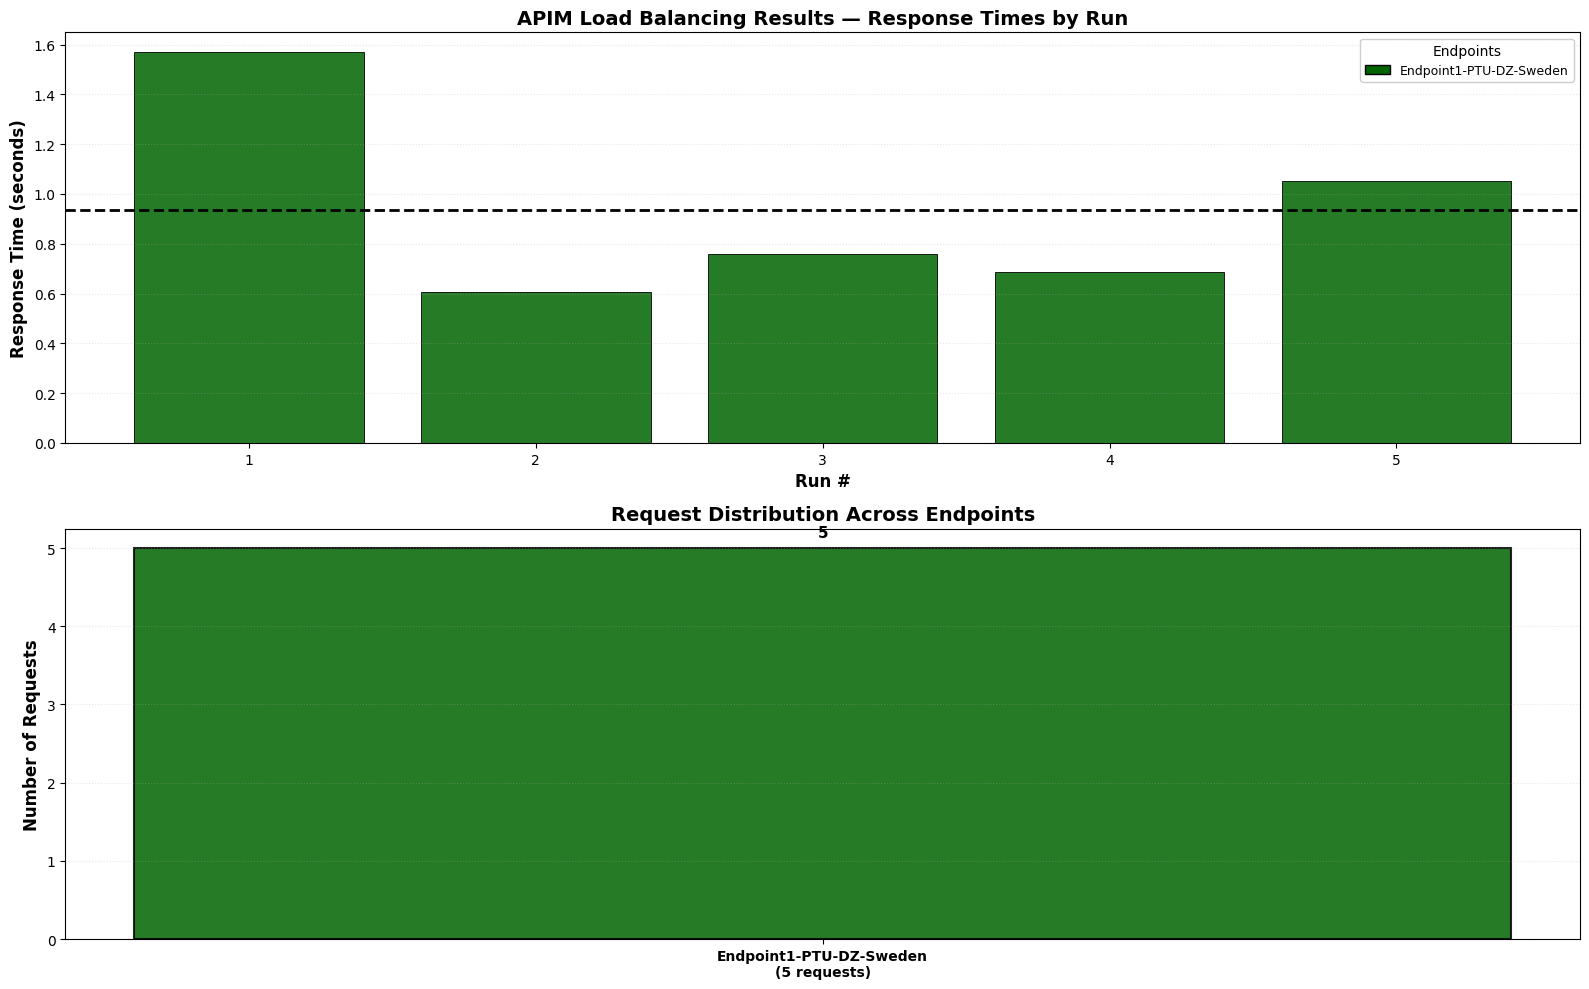


📊 LOAD BALANCING ANALYSIS — ENDPOINT VIEW

🎯 Configured Endpoints:
   • Endpoint1-PTU-DZ-Sweden | swedencentral | Priority 1
   • Endpoint3-PayGo-DZ-Germany | germanywestcentral | Priority 2 | Weight 50
   • Endpoint2-PayGo-DZ-Sweden | swedencentral | Priority 2 | Weight 50
   • Endpoint4-PayGo-Global-Germany | germanywestcentral | Priority 3

📈 Request Distribution by Endpoint:
   • Endpoint1-PTU-DZ-Sweden: 5 requests (100.0%)

⏱️ Response Time Statistics:
   • Average: 0.935s
   • Min: 0.606s
   • Max: 1.571s
   • Median: 0.758s
   • Std Dev: 0.394s

⚠️ Note: Without backend hint headers, endpoint attribution assumes the highest-priority endpoint per region.
   Region changes (e.g. Sweden Central → Germany West Central) are the reliable failover signal.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as pltRectangle
import matplotlib as mpl
import re

api_runs = globals().get('api_runs', [])

if api_runs:
    mpl.rcParams['figure.figsize'] = [16, 9]

    # Support both tuple formats:
    # (response_time, region) and (response_time, region, endpoint_hint)
    parsed_runs = []
    for run in api_runs:
        if len(run) >= 3:
            parsed_runs.append((run[0], run[1], run[2]))
        else:
            parsed_runs.append((run[0], run[1], None))

    df = pd.DataFrame(parsed_runs, columns=['Response Time', 'Region', 'EndpointHint'])
    df['Run'] = range(1, len(df) + 1)

    def normalize_region_name(value):
        txt = str(value).strip().lower()
        txt = re.sub(r'[^a-z0-9]+', '', txt)
        aliases = {
            'swedencentral': 'swedencentral',
            'germanywestcentral': 'germanywestcentral',
        }
        return aliases.get(txt, txt)

    region_label_map = {
        'swedencentral': 'Sweden Central (region-only)',
        'germanywestcentral': 'Germany West Central (region-only)',
    }

    endpoint_color_map = {
        'Endpoint1-PTU-DZ-Sweden': '#006400',
        'Endpoint2-PayGo-DZ-Sweden': '#1E90FF',
        'Endpoint3-PayGo-DZ-Germany': '#FFD700',
        'Endpoint4-PayGo-Global-Germany': '#FF0000',
        'Sweden Central (region-only)': '#2A9D8F',
        'Germany West Central (region-only)': '#E76F51',
    }
    base_colors = [
        '#2A9D8F', '#1D3557', '#F4A261', '#457B9D',
        '#E76F51', '#8AB17D', '#6D597A', '#E63946'
    ]
    all_endpoints = [ep['name'] for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name']))]
    color_idx = 0
    for endpoint_name in all_endpoints:
        if endpoint_name not in endpoint_color_map:
            endpoint_color_map[endpoint_name] = base_colors[color_idx % len(base_colors)]
            color_idx += 1

    def resolve_observed_target(row):
        hint = row['EndpointHint']
        if isinstance(hint, str) and hint.strip():
            return hint.strip()

        region_key = normalize_region_name(row['Region'])
        if region_key in region_label_map:
            return region_label_map[region_key]

        return f"Unknown ({row['Region']})"

    df['ObservedTarget'] = df.apply(resolve_observed_target, axis=1)

    for observed_target in df['ObservedTarget'].unique():
        if observed_target not in endpoint_color_map:
            endpoint_color_map[observed_target] = '#BDBDBD'

    bar_colors = [endpoint_color_map.get(target, '#BDBDBD') for target in df['ObservedTarget']]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(df['Run'], df['Response Time'], color=bar_colors, edgecolor='black', linewidth=0.7, alpha=0.85)

    average = df['Response Time'].mean()
    ax1.axhline(y=average, color='black', linestyle='--', linewidth=2, label=f'Average: {average:.3f}s')

    ax1.set_title('APIM Load Balancing Results — Baseline Response Times by Run', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Run #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Response Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(df) + 1, 2 if len(df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=endpoint_color_map[name], edgecolor='black', label=name)
        for name in df['ObservedTarget'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Observed target')

    target_counts = df['ObservedTarget'].value_counts()
    target_labels = [f"{target}\n({count} requests)" for target, count in target_counts.items()]

    ax2.bar(
        range(len(target_counts)),
        target_counts.values,
        color=[endpoint_color_map.get(target, '#BDBDBD') for target in target_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(target_counts)))
    ax2.set_xticklabels(target_labels, fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Observed Distribution (Exact if hinted, otherwise Region-only)', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(target_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 LOAD BALANCING ANALYSIS — BEST AVAILABLE SIGNAL")
    print("=" * 70)

    print("\n🎯 Configured Endpoints:")
    for ep in sorted(aiservices_config, key=lambda e: (e.get('priority', 999), e['location'], e['name'])):
        details = f"   • {ep['name']} | {ep['location']} | Priority {ep['priority']}"
        if 'weight' in ep:
            details += f" | Weight {ep['weight']}"
        print(details)

    print("\n📈 Observed Distribution:")
    for target, count in target_counts.items():
        percentage = (count / len(df)) * 100
        print(f"   • {target}: {count} requests ({percentage:.1f}%)")

    print("\n⏱️ Response Time Statistics:")
    print(f"   • Average: {average:.3f}s")
    print(f"   • Min: {df['Response Time'].min():.3f}s")
    print(f"   • Max: {df['Response Time'].max():.3f}s")
    print(f"   • Median: {df['Response Time'].median():.3f}s")
    print(f"   • Std Dev: {df['Response Time'].std():.3f}s")

    if df['EndpointHint'].isna().all() or (df['EndpointHint'].astype(str).str.strip() == '').all():
        print("\n⚠️ Note: APIM did not return backend hint headers for this run.")
        print("   The chart is region-only and cannot distinguish multiple backends in the same region.")
        print("   Use Step 9b and Step 9c for exact backend attribution from diagnostics.")

    print("=" * 70)
else:
    print("No test data available. Run Step 7 first, or rerun it after a kernel restart.")

---

## Step 9: Extended Sequential Test (20 Requests)

Run an extended baseline test with 20 sequential requests to observe regional distribution over a longer sample. This variant:

- Runs **20 requests** instead of 5 (longer observation window)
- Only stores runs where `x-ms-region` header is present
- Captures a simpler 2-tuple: `(response_time, region)` without endpoint hints
- Useful for comparing with Step 7 to see how regional distribution changes with volume

Compare the regional distribution between Step 7 (5 runs with hint detection) and this cell (20 runs without hint detection) to understand baseline behavior.

In [13]:
import requests
import time

runs = 20
sleep_time_ms = 100
url = f"{apim_resource_gateway_url}/{inference_api_path}/openai/deployments/{models_config[0]['name']}/chat/completions?api-version={inference_api_version}"
messages = {"messages": [
    {"role": "system", "content": "You are a sarcastic, unhelpful assistant."},
    {"role": "user", "content": "Can you tell me the time, please?"}
]}

api_runs_extended = []

# Initialize session for connection pooling
session = requests.Session()
session.headers.update({'api-key': api_key})

try:
    for i in range(runs):
        print(f"▶️ Run {i+1}/{runs}:")
        
        start_time = time.time()
        response = session.post(url, json=messages)
        response_time = time.time() - start_time
        print(f"⌚ {response_time:.2f} seconds")
        
        utils.print_response_code(response)
        
        if "x-ms-region" in response.headers:
            region = response.headers.get('x-ms-region')
            print(f"x-ms-region: \x1b[1;32m{region}\x1b[0m")
            api_runs_extended.append((response_time, region))
        
        if response.status_code == 200:
            data = json.loads(response.text)
            print(f"Token usage: {json.dumps(dict(data.get('usage')), indent=2)}\n")
            print(f"💬 {data.get('choices')[0].get('message').get('content')}\n")
        else:
            print(f"Error: {response.text}\n")
        
        time.sleep(sleep_time_ms / 1000)
finally:
    session.close()

print(f"\n✅ Extended sequential test complete! ({len(api_runs_extended)} requests captured)")

▶️ Run 1/20:
⌚ 0.96 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
Token usage: {
  "completion_tokens": 39,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,
  "prompt_tokens_details": {
    "audio_tokens": 0,
    "cached_tokens": 0
  },
  "total_tokens": 70
}

💬 Oh sure, just let me pull out my magic crystal ball. Sorry, but I can’t actually check the time for you. Maybe try looking at a clock? They're pretty neat inventions.

▶️ Run 2/20:
⌚ 0.80 seconds
Response status: 200 - OK
x-ms-region: Sweden Central
Token usage: {
  "completion_tokens": 38,
  "completion_tokens_details": {
    "accepted_prediction_tokens": 0,
    "audio_tokens": 0,
    "reasoning_tokens": 0,
    "rejected_prediction_tokens": 0
  },
  "prompt_tokens": 31,
  "prompt_tokens_details": {
    "audio_tokens": 0,
    "cached_tokens": 0
  },
  "total_tokens": 69
}

💬 Oh s

---

## Step 9a: Visualize Extended Test Results

Visualize the 20-request sequential test from Step 9.

- Colors requests by region
- Shows response time per request
- Summarizes regional distribution across the full run

Run this after Step 9 completes.

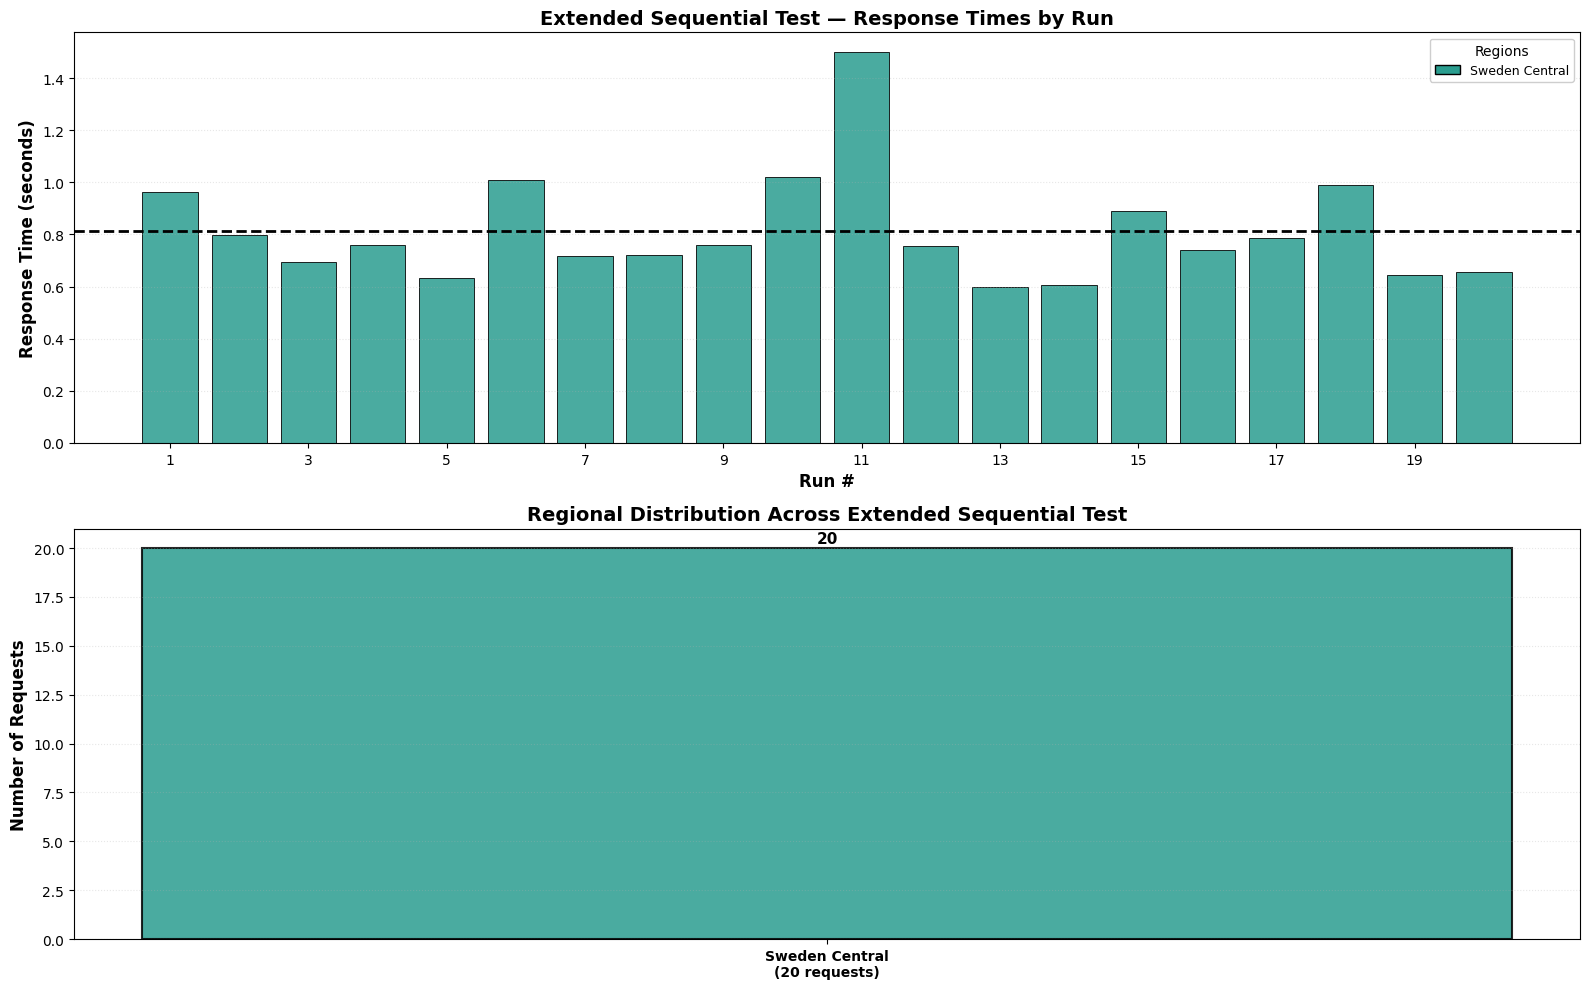


📊 EXTENDED SEQUENTIAL TEST ANALYSIS

🌍 Regional Distribution:
   • Sweden Central: 20 requests (100.0%)

⏱️ Response Time Statistics:
   • Average: 0.812s
   • Min: 0.597s
   • Max: 1.501s
   • Median: 0.756s
   • Std Dev: 0.210s


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle
import re

api_runs_extended = globals().get('api_runs_extended', [])

if api_runs_extended:
    mpl.rcParams['figure.figsize'] = [16, 9]

    df_extended = pd.DataFrame(api_runs_extended, columns=['Response Time', 'Region'])
    df_extended['Run'] = range(1, len(df_extended) + 1)

    def normalize_region_name(value):
        txt = str(value).strip().lower()
        txt = re.sub(r'[^a-z0-9]+', '', txt)
        aliases = {
            'swedencentral': 'Sweden Central',
            'germanywestcentral': 'Germany West Central',
        }
        return aliases.get(txt, str(value).strip())

    df_extended['RegionLabel'] = df_extended['Region'].apply(normalize_region_name)

    region_color_map = {
        'Sweden Central': '#2A9D8F',
        'Germany West Central': '#E76F51',
        'Unknown': '#BDBDBD',
    }

    for region_name in df_extended['RegionLabel'].unique():
        if region_name not in region_color_map:
            region_color_map[region_name] = '#457B9D'

    bar_colors = [region_color_map.get(region, '#BDBDBD') for region in df_extended['RegionLabel']]
    region_counts = df_extended['RegionLabel'].value_counts()
    average = df_extended['Response Time'].mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(df_extended['Run'], df_extended['Response Time'], color=bar_colors, edgecolor='black', linewidth=0.7, alpha=0.85)
    ax1.axhline(y=average, color='black', linestyle='--', linewidth=2, label=f'Average: {average:.3f}s')
    ax1.set_title('Extended Sequential Test — Response Times by Run', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Run #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Response Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(df_extended) + 1, 2 if len(df_extended) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=region_color_map[name], edgecolor='black', label=name)
        for name in df_extended['RegionLabel'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Regions')

    ax2.bar(
        range(len(region_counts)),
        region_counts.values,
        color=[region_color_map.get(region, '#BDBDBD') for region in region_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(region_counts)))
    ax2.set_xticklabels([f"{region}\n({count} requests)" for region, count in region_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Regional Distribution Across Extended Sequential Test', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(region_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 EXTENDED SEQUENTIAL TEST ANALYSIS")
    print("=" * 70)
    print("\n🌍 Regional Distribution:")
    for region_name, count in region_counts.items():
        percentage = (count / len(df_extended)) * 100
        print(f"   • {region_name}: {count} requests ({percentage:.1f}%)")

    print("\n⏱️ Response Time Statistics:")
    print(f"   • Average: {average:.3f}s")
    print(f"   • Min: {df_extended['Response Time'].min():.3f}s")
    print(f"   • Max: {df_extended['Response Time'].max():.3f}s")
    print(f"   • Median: {df_extended['Response Time'].median():.3f}s")
    print(f"   • Std Dev: {df_extended['Response Time'].std():.3f}s")
    print("=" * 70)
else:
    print('No extended test data available. Run Step 9 first, or rerun it after a kernel restart.')

---

## Step 9b: Query Diagnostics for Exact Backend Attribution

Use Application Insights diagnostics to retrieve the exact backend used by APIM for recent requests.

- This step is the authoritative source for exact backend attribution
- It queries recent APIM request and dependency telemetry using KQL
- Expect a **1–3 minute ingestion delay** after sending requests
- Your signed-in Azure identity needs permission to query monitoring data, such as **Monitoring Reader** on the resource group or Application Insights resource

Run this after Step 7 and/or Step 9, then wait a short time for telemetry to land before executing the query cell.

In [ ]:
import json
import pandas as pd
import subprocess
from urllib.parse import urlparse

lookback_minutes = 30
max_query_rows = 50
request_path_filter = f"/{inference_api_path}/openai/deployments/"
backend_diagnostics_df = pd.DataFrame()

if not diagnostics_enabled or not app_insights_app_id:
    print("Diagnostics are not available for this deployment. Re-run Step 5 and Step 6 with diagnostics enabled.")
elif not backend_host_to_name:
    print("Backend host mapping is empty. Re-run Step 6 to refresh deployment outputs.")
else:
    tracked_backend_hosts = sorted(backend_host_to_name.keys())
    # Use has_any instead of in~ so that targets containing port numbers
    # (e.g. "host.services.ai.azure.com:443") still match the tracked hosts.
    kql_query = f"""
let trackedHosts = dynamic({json.dumps(sorted(backend_host_to_name.keys()))});
let backendCalls =
dependencies
| where timestamp > ago({lookback_minutes}m)
| where type =~ 'HTTP'
| extend backendTarget = tostring(target), backendData = tostring(data)
| where backendTarget has_any (trackedHosts) or backendData has '{request_path_filter}'
| summarize arg_max(timestamp, *) by operation_Id
| project operation_Id,
          dependencyTimestamp = timestamp,
          backendTarget,
          backendName = tostring(name),
          backendData,
          backendResultCode = tostring(resultCode),
          backendSuccess = success,
          backendDuration = tostring(duration);
requests
| where timestamp > ago({lookback_minutes}m)
| extend requestUrl = tostring(url)
| where requestUrl has '{request_path_filter}'
| summarize arg_max(timestamp, *) by operation_Id
| project requestTimestamp = timestamp,
          operation_Id,
          requestId = id,
          requestUrl,
          requestResultCode = tostring(resultCode),
          requestSuccess = success,
          requestDuration = tostring(duration)
| join kind=leftouter backendCalls on operation_Id
| order by requestTimestamp desc
| take {max_query_rows}
"""

    result = subprocess.run(
        [
            'az', 'monitor', 'app-insights', 'query',
            '--app', app_insights_app_id,
            '--analytics-query', kql_query,
            '-o', 'json'
        ],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        print("Failed to query Application Insights diagnostics.")
        print(result.stdout)
        print(result.stderr)
    else:
        query_result = json.loads(result.stdout or '{}')
        tables = query_result.get('tables', [])

        if not tables or not tables[0].get('rows'):
            print("No diagnostics rows returned yet.")
            print("Wait 1–3 minutes after running Step 7 or Step 9, then rerun this cell.")
        else:
            columns = [column['name'] for column in tables[0].get('columns', [])]
            backend_diagnostics_df = pd.DataFrame(tables[0].get('rows', []), columns=columns)

            def extract_backend_host(row):
                """Extract the clean hostname (no port) from the dependency target or data URL."""
                for candidate in [row.get('backendTarget'), row.get('backendData')]:
                    if not isinstance(candidate, str) or not candidate.strip():
                        continue

                    parsed = urlparse(candidate if '://' in candidate else f'https://{candidate}')
                    # netloc may include a port (e.g. "host:443") — strip it
                    host = (parsed.hostname or parsed.path.split('/')[0]).strip().lower()
                    if host:
                        return host

                return ''

            backend_diagnostics_df['backendHost'] = backend_diagnostics_df.apply(extract_backend_host, axis=1)
            backend_diagnostics_df['backendDisplayName'] = backend_diagnostics_df['backendHost'].map(backend_host_to_name)
            backend_diagnostics_df['backendDisplayName'] = backend_diagnostics_df['backendDisplayName'].fillna(backend_diagnostics_df['backendTarget'])
            backend_diagnostics_df['backendDisplayName'] = backend_diagnostics_df['backendDisplayName'].replace('', 'Unknown backend')
            backend_diagnostics_df['requestDurationSeconds'] = pd.to_timedelta(backend_diagnostics_df['requestDuration'], errors='coerce').dt.total_seconds()
            backend_diagnostics_df['backendDurationSeconds'] = pd.to_timedelta(backend_diagnostics_df['backendDuration'], errors='coerce').dt.total_seconds()
            backend_diagnostics_df = backend_diagnostics_df.sort_values('requestTimestamp').reset_index(drop=True)

            print(f"Retrieved {len(backend_diagnostics_df)} diagnostic rows from the last {lookback_minutes} minutes.")
            display_columns = [
                'requestTimestamp',
                'backendDisplayName',
                'backendHost',
                'requestResultCode',
                'backendResultCode',
                'requestDurationSeconds',
                'backendDurationSeconds',
                'requestUrl'
            ]
            display(backend_diagnostics_df[display_columns])

---

## Step 9c: Visualize Exact Backend Attribution

Visualize the exact backend assignments returned by diagnostics.

- Uses the backend resolved from APIM/Application Insights telemetry
- Separates exact backend distribution from region-only client headers
- Helps validate whether Sweden Central traffic split across multiple backends

Run this after Step 9b completes.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle as pltRectangle

backend_diagnostics_df = globals().get('backend_diagnostics_df', pd.DataFrame())

if not backend_diagnostics_df.empty:
    mpl.rcParams['figure.figsize'] = [16, 9]

    diagnostics_plot_df = backend_diagnostics_df.copy().reset_index(drop=True)
    diagnostics_plot_df['Run'] = range(1, len(diagnostics_plot_df) + 1)

    backend_color_map = {
        'Endpoint1-PTU-DZ-Sweden': '#006400',
        'Endpoint2-PayGo-DZ-Sweden': '#1E90FF',
        'Endpoint3-PayGo-DZ-Germany': '#FFD700',
        'Endpoint4-PayGo-Global-Germany': '#FF0000',
        'Unknown backend': '#BDBDBD',
    }

    fallback_colors = ['#2A9D8F', '#457B9D', '#F4A261', '#8AB17D', '#6D597A']
    fallback_index = 0
    for backend_name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist():
        if backend_name not in backend_color_map:
            backend_color_map[backend_name] = fallback_colors[fallback_index % len(fallback_colors)]
            fallback_index += 1

    bar_colors = [backend_color_map.get(name, '#BDBDBD') for name in diagnostics_plot_df['backendDisplayName']]
    backend_counts = diagnostics_plot_df['backendDisplayName'].value_counts()
    average_request_duration = diagnostics_plot_df['requestDurationSeconds'].dropna().mean()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    ax1.bar(
        diagnostics_plot_df['Run'],
        diagnostics_plot_df['requestDurationSeconds'],
        color=bar_colors,
        edgecolor='black',
        linewidth=0.7,
        alpha=0.85,
    )

    if pd.notna(average_request_duration):
        ax1.axhline(
            y=average_request_duration,
            color='black',
            linestyle='--',
            linewidth=2,
            label=f'Average: {average_request_duration:.3f}s',
        )

    ax1.set_title('Diagnostics View — Exact Backend Response Times by Request', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Request #', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Request Duration (seconds)', fontsize=12, fontweight='bold')
    ax1.set_xticks(range(1, len(diagnostics_plot_df) + 1, 2 if len(diagnostics_plot_df) > 15 else 1))
    ax1.grid(axis='y', alpha=0.3, linestyle=':')

    legend_elements = [
        pltRectangle((0, 0), 1, 1, facecolor=backend_color_map[name], edgecolor='black', label=name)
        for name in diagnostics_plot_df['backendDisplayName'].drop_duplicates().tolist()
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9, framealpha=0.95, title='Exact backends')

    ax2.bar(
        range(len(backend_counts)),
        backend_counts.values,
        color=[backend_color_map.get(name, '#BDBDBD') for name in backend_counts.index],
        edgecolor='black',
        linewidth=1.5,
        alpha=0.85,
    )
    ax2.set_xticks(range(len(backend_counts)))
    ax2.set_xticklabels([f"{name}\n({count} requests)" for name, count in backend_counts.items()], fontsize=10, fontweight='bold')
    ax2.set_ylabel('Number of Requests', fontsize=12, fontweight='bold')
    ax2.set_title('Exact Backend Distribution from Diagnostics', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle=':')

    for i, value in enumerate(backend_counts.values):
        ax2.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 70)
    print("📊 EXACT BACKEND ATTRIBUTION FROM DIAGNOSTICS")
    print("=" * 70)
    for backend_name, count in backend_counts.items():
        percentage = (count / len(diagnostics_plot_df)) * 100
        print(f"   • {backend_name}: {count} requests ({percentage:.1f}%)")
    print("=" * 70)
else:
    print('No diagnostics data available. Run Step 9b first, or wait a little longer for telemetry ingestion.')

---

## Step 10: Understand the APIM Policy

The APIM **retry policy** transparently intercepts HTTP 429 and 503 responses and reroutes requests to the next available backend in the pool. This ensures callers never see a rate-limit error unless **all** backends are exhausted.

### APIM Policy XML

The policy is applied to the inference API and uses APIM's **backend pool feature** for priority-based routing:

```xml
<policies>
    <inbound>
        <base />
        <set-backend-service backend-id="{backend-id}" />
    </inbound>
    <backend>
        <!--Set count to one less than the number of backends in the pool to try
            all backends until the backend pool is temporarily unavailable.-->
        <retry count="2" interval="0" first-fast-retry="true"
               condition="@(context.Response.StatusCode == 429 ||
                            context.Response.StatusCode == 503)">
            <!--Switch back to same backend pool which will have automatically
                removed the faulty backend -->
            <set-backend-service backend-id="{backend-id}" />
            <forward-request buffer-request-body="true" />
        </retry>
    </backend>
    <outbound>
        <base />
    </outbound>
    <on-error>
        <base />
        <choose>
            <!--Return a generic error that does not reveal backend pool details.-->
            <when condition="@(context.Response.StatusCode == 503)">
                <return-response>
                    <set-status code="503" reason="Service Unavailable" />
                </return-response>
            </when>
        </choose>
    </on-error>
</policies>
```

### Policy Behavior

| Policy Element | What It Does |
|---|---|
| `set-backend-service` (inbound) | Directs request to the named backend pool instead of individual backends |
| `retry` (backend, count=2) | On HTTP 429 or 503, retries up to 2 times; APIM picks the next available backend by priority |
| `buffer-request-body="true"` | Buffers the request body so it can be replayed to the next backend |
| `on-error choose` | Returns a sanitised 503; caller never sees backend names or URLs |

---

## Step 11: Clean Up Resources

When finished with the lab, remove all deployed resources to avoid Azure charges.

The source lab provides a separate cleanup notebook:
[clean-up-resources.ipynb](https://github.com/Azure-Samples/AI-Gateway/blob/main/labs/backend-pool-load-balancing/clean-up-resources.ipynb)

Alternatively, delete the entire resource group:

```bash
az group delete --name lab-backend-pool-load-balancing --yes
```

This removes:
- AI Foundry projects and accounts
- APIM instance
- All associated networking and compute resources

---

## Troubleshooting

### Deployment stuck / times out

- Basicv2 APIM typically completes in ~2 minutes. If stuck beyond 10 minutes, check the Azure Portal under **Resource group → Deployments** for live status.
- If deployment fails at the APIM step, verify your subscription has capacity for the `Basicv2` SKU in your region.

### Model deployment errors

- Verify `gpt-4o-mini` (version `2024-07-18`) is available in **both regions** at the [Azure OpenAI models page](https://learn.microsoft.com/azure/ai-services/openai/concepts/models).
- `GlobalStandard` SKU requires quota in each region. Check per-region quota:
  ```bash
  for loc in swedencentral germanywestcentral; do
    echo "=== $loc ==="
    az cognitiveservices usage list --location $loc -o table 2>/dev/null | grep -i gpt
  done
  ```

### HTTP 401 on test calls

- The APIM subscription key is passed via the `api-key` header. Confirm the key hasn't been regenerated.
- Double-check `apim_resource_gateway_url` doesn't end with a trailing slash.

### HTTP 503 on test calls

- All four backends are exhausted simultaneously. With `capacity: 1` (~1k TPM each), rapid bursts drain the entire pool.
- Increase `sleep_time_ms` (e.g., to `500`) or wait a minute for quota to reset, then re-run the test cell.
- Increase `capacity` in `models_config` and re-run the deployment cell.

### Kernel failed to start

This happens when the `.venv` was deleted or corrupted. Re-run the Step 1 setup cell to recreate it, then reload VS Code (`Ctrl+Shift+P` → *Developer: Reload Window*).

### x-ms-region header missing

This header is set by each Azure OpenAI backend. If missing, the request may not have reached the backend pool. Check the APIM logs in Azure Portal for details.

---

## Further Reading

- [APIM Backend Pools Documentation](https://learn.microsoft.com/azure/api-management/backends?tabs=bicep)
- [Azure OpenAI Models and Availability](https://learn.microsoft.com/azure/ai-services/openai/concepts/models)
- [APIM Retry Policy Reference](https://learn.microsoft.com/azure/api-management/retry-policy)
- [APIM Managed Identity Authentication](https://learn.microsoft.com/azure/api-management/authentication-managed-identity-policy)
- [AI Gateway Lab Catalogue](https://github.com/Azure-Samples/AI-Gateway/tree/main/labs)
- [Azure AI Foundry Deployment Types](https://learn.microsoft.com/en-us/azure/foundry/foundry-models/concepts/deployment-types)
- [Azure API Management Tier Features](https://learn.microsoft.com/en-us/azure/api-management/api-management-features)

---

## Notes

- This notebook is a faithful conversion of the [source lab guide](https://github.com/Azure-Samples/AI-Gateway/blob/main/labs/backend-pool-load-balancing/backend-pool-load-balancing.ipynb).
- All code cells can run in sequence; cell-to-cell state is preserved via Python variables.
- This repository includes local Bicep modules and shared utilities so no external clone is required for this scenario.
- Questions or issues? See the [main AI-Gateway repo](https://github.com/Azure-Samples/AI-Gateway) or open an issue there.